<a href="https://colab.research.google.com/github/institutohumai/cursos-python/blob/master/AnalisisDeDatos/2_Pivot_Table_y_Joins/clase-2-ejercicios.ipynb"> <img src='https://colab.research.google.com/assets/colab-badge.svg' /> </a>
<div align="center"> Recordá abrir en una nueva pestaña </div>


# Ejercicios Pandas II

In [23]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline

## Parámetros y extracción de datos

In [24]:
ESTIMACIONES_URL = "http://datos.agroindustria.gob.ar/dataset/9e1e77ba-267e-4eaa-a59f-3296e86b5f36/resource/95d066e6-8a0f-4a80-b59d-6f28f88eacd5/download/estimaciones-agricolas-al-30-09-2019.csv"
ESTIMACIONES_URL_S3 = "https://storage.googleapis.com/humai-datasets/aws_s3/analisis_de_datos/2_Pivot_Table_y_Joins/ejercicios/estimaciones_agricolas.zip"
ESTIMACIONES_PATH = "data/estimaciones-agricolas.csv"

In [25]:
converters = {
    "id_provincia": lambda x: str(x).zfill(2),
    "id_departamento": lambda x: str(x).zfill(3),
}

#estimaciones = pd.read_csv(ESTIMACIONES_URL, encoding="latin1", converters=converters)estimaciones = pd.read_csv(ESTIMACIONES_URL, encoding="latin1", converters=converters)
estimaciones = pd.read_csv(ESTIMACIONES_URL_S3, encoding="utf8", converters=converters)
#estimaciones.to_csv(ESTIMACIONES_PATH, encoding="utf8", index=False)
#estimaciones = pd.read_csv(ESTIMACIONES_PATH, converters=converters)

## Ejercicios

Explorar descriptivamente el dataset de estimaciones agrícolas (https://datos.gob.ar/dataset/agroindustria-agricultura---estimaciones-agricolas) usando los elementos aprendidos en la clase 2.

Intentemos mostrar la información usando el método `plot()` y aprovechar `pivot_table` para condensar y/o agregar la información.

### 1. Comencemos explorando un poco los datos ¿Ves algún problema en los nombres de las columnas?

In [26]:
print(estimaciones.columns)
estimaciones.columns = estimaciones.columns.str.strip()
print(estimaciones.columns)

Index(['id_provincia', 'provincia', 'id_departamento', 'departamento',
       'id_cultivo', 'cultivo', 'id_campaña', 'campaña', 'sup_sembrada ',
       'sup_cosechada', 'produccion ', 'rendimiento'],
      dtype='str')
Index(['id_provincia', 'provincia', 'id_departamento', 'departamento',
       'id_cultivo', 'cultivo', 'id_campaña', 'campaña', 'sup_sembrada',
       'sup_cosechada', 'produccion', 'rendimiento'],
      dtype='str')


In [27]:
print(estimaciones.shape)
print(estimaciones.columns)
print(estimaciones.info())

(136051, 12)
Index(['id_provincia', 'provincia', 'id_departamento', 'departamento',
       'id_cultivo', 'cultivo', 'id_campaña', 'campaña', 'sup_sembrada',
       'sup_cosechada', 'produccion', 'rendimiento'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 136051 entries, 0 to 136050
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   id_provincia     136051 non-null  str  
 1   provincia        136051 non-null  str  
 2   id_departamento  136051 non-null  str  
 3   departamento     136051 non-null  str  
 4   id_cultivo       136051 non-null  int64
 5   cultivo          136051 non-null  str  
 6   id_campaña       136051 non-null  int64
 7   campaña          136051 non-null  str  
 8   sup_sembrada     136051 non-null  int64
 9   sup_cosechada    136051 non-null  int64
 10  produccion       136051 non-null  int64
 11  rendimiento      136051 non-null  int64
dtypes: int64(6), str(6)
memory usage: 1

In [28]:
estimaciones = estimaciones.rename(columns={
    "id_campaña": "id_campania",
    "campaña": "campania",
})

In [29]:
estimaciones.sample(5)

,id_provincia,provincia,id_departamento,departamento,id_cultivo,cultivo,id_campania,campania,sup_sembrada,sup_cosechada,produccion,rendimiento
16891,06,BUENOS AIRES,210,CHACABUCO,14,Girasol,9,1977/1978,5500,5005,5700,1139
72829,30,ENTRE RIOS,028,FEDERACION,4,Arroz,47,2015/2016,8600,8200,64200,7829
128174,86,SANTIAGO DEL ESTERO,070,FIGUEROA,32,Maíz,5,1973/1974,1600,300,210,700
61686,14,CORDOBA,147,SANTA MARIA,24,Poroto seco,7,1975/1976,10110,9950,6965,700
110894,70,SAN JUAN,063,9 DE JULIO,11,Cebolla total,6,1974/1975,150,150,4500,30000


### 2. ¿Cuál es la producción agrícola total en cada año?

* Observemos la columna "campaña". Esta columna representa los períodos de producción como un string con año de inicio y fin ¿Podríamos transformarlo en un valor numérico?

In [30]:
estimaciones.campania.unique()

<StringArray>
['1969/1970', '1970/1971', '1971/1972', '1972/1973', '1973/1974', '1974/1975',
 '1975/1976', '1976/1977', '1977/1978', '1978/1979', '1979/1980', '1980/1981',
 '1983/1984', '1984/1985', '1985/1986', '1986/1987', '1987/1988', '1981/1982',
 '1982/1983', '1989/1990', '1990/1991', '1991/1992', '1992/1993', '1993/1994',
 '1994/1995', '1995/1996', '1996/1997', '1997/1998', '1988/1989', '1999/2000',
 '2000/2001', '1998/1999', '2001/2002', '2002/2003', '2003/2004', '2004/2005',
 '2005/2006', '2006/2007', '2007/2008', '2008/2009', '2009/2010', '2010/2017',
 '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017',
 '2017/2018', '2018/2019']
Length: 50, dtype: str

In [31]:
# corregir la camapaña 2010/2017 a 2010/2011
estimaciones["campania"] = estimaciones.campania.str.replace("2010/2017", "2010/2011")
estimaciones.campania.unique()

<StringArray>
['1969/1970', '1970/1971', '1971/1972', '1972/1973', '1973/1974', '1974/1975',
 '1975/1976', '1976/1977', '1977/1978', '1978/1979', '1979/1980', '1980/1981',
 '1983/1984', '1984/1985', '1985/1986', '1986/1987', '1987/1988', '1981/1982',
 '1982/1983', '1989/1990', '1990/1991', '1991/1992', '1992/1993', '1993/1994',
 '1994/1995', '1995/1996', '1996/1997', '1997/1998', '1988/1989', '1999/2000',
 '2000/2001', '1998/1999', '2001/2002', '2002/2003', '2003/2004', '2004/2005',
 '2005/2006', '2006/2007', '2007/2008', '2008/2009', '2009/2010', '2010/2011',
 '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017',
 '2017/2018', '2018/2019']
Length: 50, dtype: str

In [32]:
estimaciones_campanias = estimaciones.campania.str.split("/", expand=True)
estimaciones[["campania_inicio", "campania_fin"]] = estimaciones.campania.str.split("/", n=1,expand=True) 
estimaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 136051 entries, 0 to 136050
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   id_provincia     136051 non-null  str  
 1   provincia        136051 non-null  str  
 2   id_departamento  136051 non-null  str  
 3   departamento     136051 non-null  str  
 4   id_cultivo       136051 non-null  int64
 5   cultivo          136051 non-null  str  
 6   id_campania      136051 non-null  int64
 7   campania         136051 non-null  str  
 8   sup_sembrada     136051 non-null  int64
 9   sup_cosechada    136051 non-null  int64
 10  produccion       136051 non-null  int64
 11  rendimiento      136051 non-null  int64
 12  campania_inicio  136051 non-null  str  
 13  campania_fin     136051 non-null  str  
dtypes: int64(6), str(8)
memory usage: 14.5 MB


In [33]:
# castear las campanias inicio y fin a int
estimaciones["campania_inicio"] = estimaciones["campania_inicio"].astype(int)
estimaciones["campania_fin"] = estimaciones["campania_fin"].astype(int)
estimaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 136051 entries, 0 to 136050
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   id_provincia     136051 non-null  str  
 1   provincia        136051 non-null  str  
 2   id_departamento  136051 non-null  str  
 3   departamento     136051 non-null  str  
 4   id_cultivo       136051 non-null  int64
 5   cultivo          136051 non-null  str  
 6   id_campania      136051 non-null  int64
 7   campania         136051 non-null  str  
 8   sup_sembrada     136051 non-null  int64
 9   sup_cosechada    136051 non-null  int64
 10  produccion       136051 non-null  int64
 11  rendimiento      136051 non-null  int64
 12  campania_inicio  136051 non-null  int64
 13  campania_fin     136051 non-null  int64
dtypes: int64(8), str(6)
memory usage: 14.5 MB


In [34]:
# ¿Cuás es la producción de cada año?
produccion_anual = estimaciones.pivot_table(
    index="campania_inicio",
    values="produccion",
    aggfunc="sum"
)
produccion_anual.head(3)

,produccion
campania_inicio,
1969,39023146
1970,37848428
1971,33719119


<Axes: title={'center': 'Producción agrícola total anual (tn)'}, xlabel='Año de inicio'>

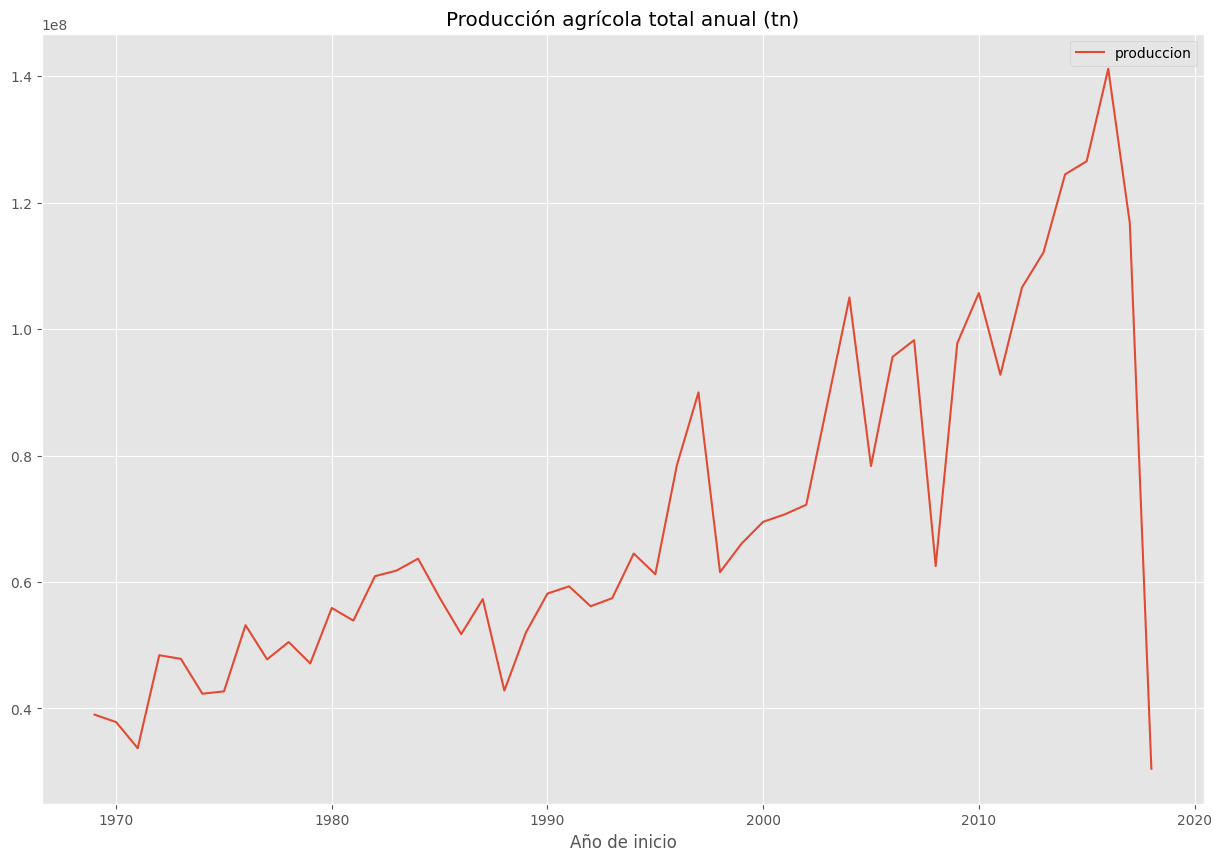

In [35]:
produccion_anual.plot(
    figsize=(15, 10),
    title="Producción agrícola total anual (tn)",
    xlabel="Año de inicio"
)

### 3. Enfoquémonos en un período específico, por ejemplo, la campaña "2017/2018":

* ¿Cuál fue la producción promedio del cultivo de soja en los departamentos que la sembraron en ese período?
* ¿Cuál es y en qué departamento está el rendimiento (kg por hectárea) mínimo, mediano y máximo en la provincia de Buenos Aires? (La mediana es el valor que, si los datos están ordenados, queda en el centro de ellos)

**Observación:**
Como no estamos viendo una variable en función de un período de tiempo como antes, quizás un gráfico de líneas no sea la mejor opción. Les sugerimos investigar sobre el parámetro *"kind"* del [método "plot" de Pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) que permite construir distintos tipos de gráficos.

In [36]:
estimaciones.cultivo.unique()

<StringArray>
[             'Ajo',          'Alpiste',            'Avena',
          'Cártamo', 'Cebada cervecera', 'Cebada forrajera',
     'Cebada total',    'Cebolla total',          'Centeno',
            'Colza',          'Girasol',            'Limón',
             'Lino',             'Maíz',        'Mandarina',
             'Maní',             'Mijo',          'Naranja',
       'Papa total',           'Pomelo',      'Poroto seco',
       'Soja total',            'Sorgo',    'Trigo candeal',
      'Trigo total',          'Algodón',           'Jojoba',
            'Arroz',   'Caña de azúcar',           'Banana',
               'Té',             'Tung',       'Yerba mate']
Length: 33, dtype: str

In [48]:
estimaciones_soja_2017_2018 =  estimaciones[
    (estimaciones.cultivo == "Soja total") &
    (estimaciones.campania == "2017/2018")
]

soja_promedio_provincia_2017_2018 = estimaciones_soja_2017_2018.pivot_table(
  index=["provincia"],
  values=["produccion"],
  aggfunc="mean"
)

soja_promedio_provincia_2017_2018.sort_values(by="produccion", inplace=True)

soja_promedio_provincia_2017_2018.head()

,produccion
provincia,
MISIONES,984.125000
JUJUY,2107.571429
CATAMARCA,29672.000000
TUCUMAN,37843.230769
CORRIENTES,40000.000000


<Axes: title={'center': 'Producción promedio de soja por provincia (tn) - Período 2017/2018'}, ylabel='provincia'>

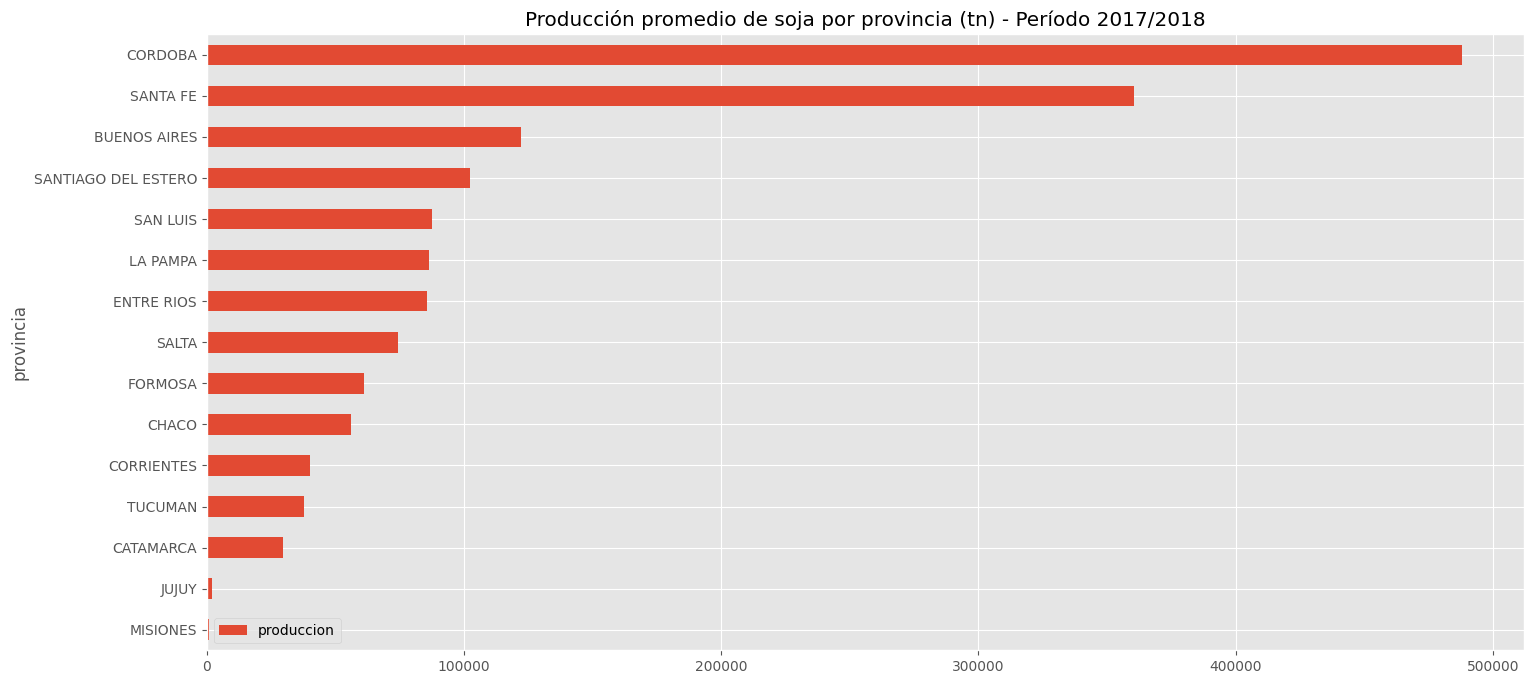

In [ ]:
# ¿Cuál fue la producción promedio del cultivo de soja en los departamentos que la sembraron en ese período?

soja_promedio_provincia_2017_2018.plot(
    kind="barh",
    title="Producción promedio de soja por provincia (tn) - Período 2017/2018",
    figsize=(17, 8)
)

In [52]:
"""
¿Cuál es y en qué departamento está el rendimiento (kg por hectárea) mínimo, mediano y máximo en la provincia de Buenos Aires?
(La mediana es el valor que, si los datos están ordenados, queda en el centro de ellos)
"""
estimaciones.provincia.unique()

<StringArray>
[       'BUENOS AIRES',           'CATAMARCA',               'CHACO',
              'CHUBUT',             'CORDOBA',          'CORRIENTES',
          'ENTRE RIOS',             'FORMOSA',               'JUJUY',
            'LA PAMPA',            'LA RIOJA',             'MENDOZA',
            'MISIONES',             'NEUQUEN',           'RIO NEGRO',
               'SALTA',            'SAN JUAN',            'SAN LUIS',
          'SANTA CRUZ',            'SANTA FE', 'SANTIAGO DEL ESTERO',
    'TIERRA DEL FUEGO',             'TUCUMAN']
Length: 23, dtype: str

In [53]:
rendimiento_por_departamento = estimaciones_soja_2017_2018 \
  .query("provincia == 'BUENOS AIRES' ") \
  .groupby('departamento') \
  .agg(
      min_rend = ("rendimiento", "min"),
      median_rend = ("rendimiento", "median"),
      max_rend = ("rendimiento", "max"),
  )

rendimiento_por_departamento

,min_rend,median_rend,max_rend
departamento,,,
25 DE MAYO,1715,1715.0,1715
9 DE JULIO,2249,2249.0,2249
ADOLFO ALSINA,1478,1478.0,1478
ADOLFO GONZALES CHAVES,1214,1214.0,1214
ALBERTI,1950,1950.0,1950
...,...,...,...
TORNQUIST,1369,1369.0,1369
TRENQUE LAUQUEN,2445,2445.0,2445
TRES ARROYOS,1230,1230.0,1230


### 4. Creá una tabla con la producción promedio de soja y otra con la de papa. Combinalas usando `merge` de modo que solo queden las campañas en las que se sembraron ambos productos.

In [54]:
estimaciones.cultivo.unique()

<StringArray>
[             'Ajo',          'Alpiste',            'Avena',
          'Cártamo', 'Cebada cervecera', 'Cebada forrajera',
     'Cebada total',    'Cebolla total',          'Centeno',
            'Colza',          'Girasol',            'Limón',
             'Lino',             'Maíz',        'Mandarina',
             'Maní',             'Mijo',          'Naranja',
       'Papa total',           'Pomelo',      'Poroto seco',
       'Soja total',            'Sorgo',    'Trigo candeal',
      'Trigo total',          'Algodón',           'Jojoba',
            'Arroz',   'Caña de azúcar',           'Banana',
               'Té',             'Tung',       'Yerba mate']
Length: 33, dtype: str

In [ ]:
panel_soja = estimaciones.query(" cultivo == 'Soja total' ") \
  .pivot_table(
      index=["campania"],
      values=["produccion"],
      aggfunc='mean'
  ).reset_index()
# panel_soja = panel_soja.rename(columns={"produccion": "soja_mean"})
panel_soja.head(3)

,campania,produccion
0,1969/1970,515.384615
1,1970/1971,983.333333
2,1971/1972,917.647059


In [59]:
panel_papa = estimaciones.query(" cultivo == 'Papa total' ") \
  .pivot_table(
      index=["campania"],
      values=["produccion"],
      aggfunc='mean'
  ).reset_index()
# panel_papa = panel_papa.rename(columns={"produccion": "papa_mean"})
panel_papa.head(3)

,campania,produccion
0,1969/1970,7357.003155
1,1970/1971,6323.734628
2,1971/1972,4368.415033


In [63]:
produccion_promedio_soja_papa = panel_soja.merge(
    panel_papa,
    left_on=["campania"],
    right_on=["campania"],
    suffixes=(
        "_promedio_soja",
        "_promedio_papa"
    )
)

produccion_promedio_soja_papa.head()

,campania,produccion_promedio_soja,produccion_promedio_papa
0,1969/1970,515.384615,7357.003155
1,1970/1971,983.333333,6323.734628
2,1971/1972,917.647059,4368.415033
3,1972/1973,2471.854545,5512.140288
4,1973/1974,2582.708333,7868.471014


<Axes: title={'center': 'Producción promedio de soja y papa, por período'}, ylabel='produccion'>

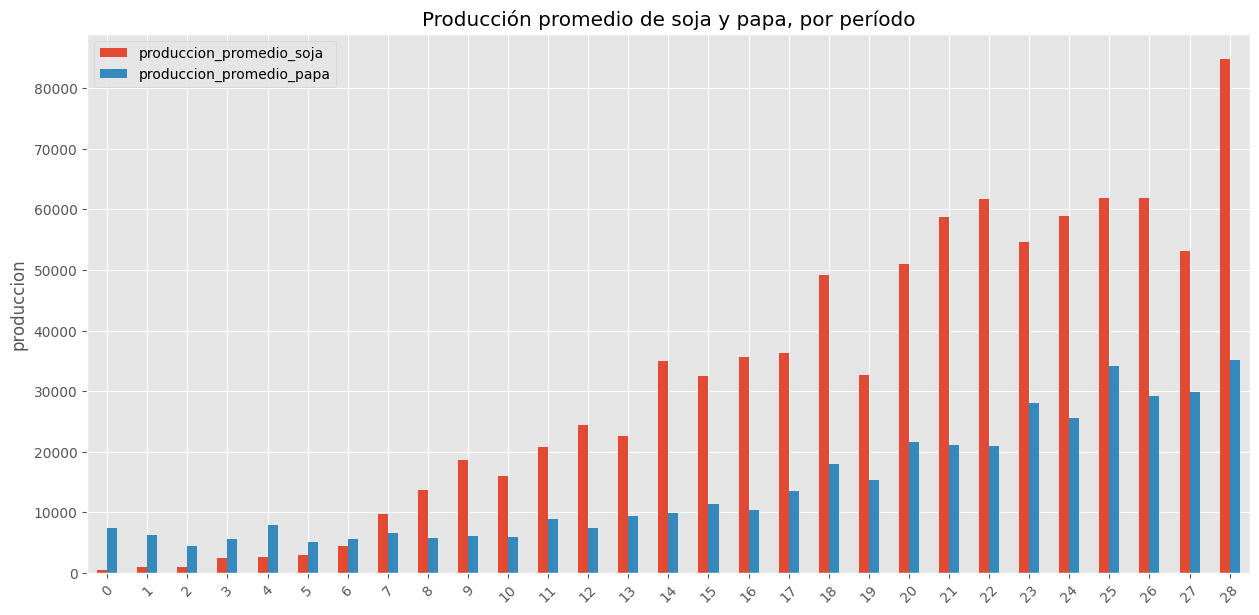

In [64]:
produccion_promedio_soja_papa.plot(
    title="Producción promedio de soja y papa, por período",
    kind="bar",
    ylabel="produccion",
    figsize=(15, 7),
    rot=(45),
    use_index=True
)

### 5. Generá una tabla donde cada cultivo sea una columna, cada fila un año (una campaña) y los valores sean la producción total de cada cultivo.

In [67]:
produccion_total_cultivos = estimaciones.pivot_table(
      index=["campania"],
      columns=["cultivo"],
      values=["produccion"],
      aggfunc="sum"
  ).reset_index()

produccion_total_cultivos.head()

campania produccion                                          \
cultivo                   Ajo   Algodón   Alpiste     Arroz     Avena   
0        1969/1970    49110.0  458200.0  107000.0  407000.0  425000.0   
1        1970/1971    49214.0  285000.0   39300.0  288000.0  359960.0   
2        1971/1972    50746.0  292200.0   26200.0  294000.0  475000.0   
3        1972/1973    54545.0  424000.0   35000.0  260000.0  566000.0   
4        1973/1974    66821.0  418400.0   34000.0  316000.0  561000.0   

                                                                    ...  \
cultivo    Banana Caña de azúcar Cebada cervecera Cebada forrajera  ...   
0        223440.0      9700000.0         499500.0          70486.0  ...   
1        224800.0     10260000.0         318500.0          48478.0  ...   
2        312700.0     12870000.0         476000.0          77000.0  ...   
3        352160.0     16870000.0         760000.0         120000.0  ...   
4        399400.0     15536000.0         608000.0         124000.0  ...   

                                                                              \
cultivo Papa total    Pomelo Poroto seco Soja total      Sorgo Trigo candeal   
0        2332170.0  130995.0     39388.0    26800.0  3820000.0           NaN   
1        1954034.0  143584.0     58920.0    59000.0  4660000.0           NaN   
2        1336735.0  139854.0     57923.0    78000.0  2360000.0           NaN   
3        1532375.0  179230.0     72791.0   271904.0  4960000.0           NaN   
4        2171698.0  177000.0    115150.0   495880.0  5900000.0           NaN   

                                                    
cultivo Trigo total      Tung        Té Yerba mate  
0         7019726.0  148600.0  111000.0    76788.0  
1         4919767.0  110000.0  129000.0    90460.0  
2         5439840.0  170000.0  131000.0   126714.0  
3         7896787.0   25000.0  128600.0   150963.0  
4         6559916.0  136000.0  140000.0   134529.0  

[5 rows x 34 columns]

<Axes: title={'center': 'Producción total de cada cultivo'}, ylabel='produccion'>

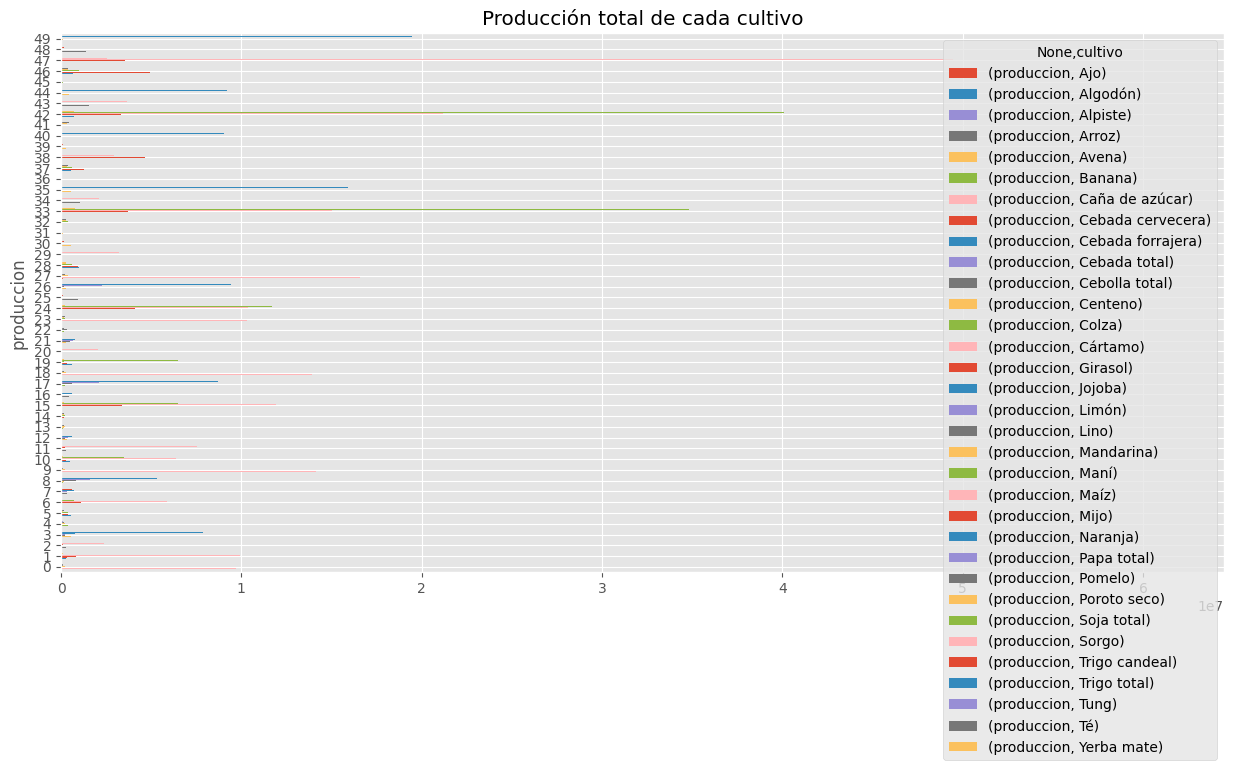

In [70]:
produccion_total_cultivos.plot(
    title="Producción total de cada cultivo",
    kind="barh",
    ylabel="produccion",
    figsize=(15, 7),
)